In [1]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)

# =============================================================================
# Domain & Solver Tolerances
# =============================================================================
R = 1.0
RAD_UNIF = 1
PROBLEM_TYPE = 0
CUSTOM_PROBLEM = None

TOL_NUFFT = 1e-10
MAXITER_NUFFT = 200
EPS_FINUFFT = 1e-15         # Clean 15-digit double precision (no warning messages)
PRECOND_SHIFT = 1e-8
KDE_OVERSAMPLE = 4
KDE_BANDWIDTH = 1.0
QUAD_RULE = 1
BC_CHOICE = 1

# =============================================================================
# Machine-Precision Base Values
# =============================================================================
BASE_MACHINE_PRECS = {
    "Unif-FFT": 0.0,
    "Unif-NUDFT": 1e-20,
    "Unif-NUFFT": 1e-20,
    "Fixed-jittered-NUDFT": 1e-20,
    "Fixed-jittered-NUFFT": 1e-20,
    "Fixed-stratified_rand-NUDFT": 1e-20,
    "Fixed-stratified_rand-NUFFT": 1e-20,
    "Fixed-rand-NUDFT": 1e-14,
    "Fixed-rand-NUFFT": 1e-12,
}

# =============================================================================
# Dedicated Lambda Tables for All 6 Independent Sweeps
# =============================================================================
LAMBDAS_6_SWEEPS = {
    # -------------------------------------------------------------------------
    # 3 Sweeps: Varying N (Fixed M = 32, 128, 512)
    # -------------------------------------------------------------------------
    "VaryN_M32": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-08},
        "Fixed-sine-NUFFT":      {32: 1e-6, 64: 1e-12, 128: 5e-6, 256: 5e-5, 512: 1e-5},
    },
    "VaryN_M128": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-08},
        "Fixed-sine-NUFFT":      {32: 1e-6, 64: 1e-12, 128: 5e-6, 256: 5e-5, 512: 1e-5},
    },
    "VaryN_M512": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": {32: 1e-16, 64: 1e-12, 128: 1e-11, 256: 1e-12, 512: 1e-11},
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      {32: 1e-16, 64: 1e-16, 128: 1e-12, 256: 1e-11, 512: 1e-08},
        "Fixed-sine-NUFFT":      {32: 1e-6, 64: 1e-12, 128: 5e-6, 256: 5e-5, 512: 1e-5},
    },

    # -------------------------------------------------------------------------
    # 3 Sweeps: Varying M (Fixed N = 32, 128, 512)
    # -------------------------------------------------------------------------
    "VaryM_N32": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": 1e-16,
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      1e-16,
        "Fixed-sine-NUFFT":      1e-6,
    },
    "VaryM_N128": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": 1e-11,
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      1e-12,
        "Fixed-sine-NUFFT":      5e-6,
    },
    "VaryM_N512": {
        **BASE_MACHINE_PRECS,
        "Fixed-clustered-NUDFT": 1e-11,
        "Fixed-clustered-NUFFT": 1e-6,
        "Fixed-sine-NUDFT":      1e-08,
        "Fixed-sine-NUFFT":      1e-05,
    },
}

# Apply global parameters
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    precond_shift=PRECOND_SHIFT,
    kde_oversample=KDE_OVERSAMPLE,
    kde_bandwidth=KDE_BANDWIDTH,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM
)

N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]

FIXED_M_LIST = [32, 128, 512]
FIXED_N_LIST = [32, 128, 512]

MUTE_OUTPUT = True

METHODS_COMP = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    dict(name="Unif-NUFFT", label="Uniform / NUFFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=False),
]
for kind in ("rand", "stratified_rand", "jittered", "clustered", "sine"):
    METHODS_COMP += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind}-NUFFT", label=f"Fixed {kind} / NUFFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=False),
    ]


c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# =============================================================================
# Run All 6 Sweeps With Their Dedicated Lambda Configurations
# =============================================================================
print("\nRunning Accuracy Comparisons Across All 6 Sweeps...")

df_cN_by_M = {}
for fixed_m in FIXED_M_LIST:
    sweep_table = LAMBDAS_6_SWEEPS[f"VaryN_M{fixed_m}"]
    df_cN_by_M[fixed_m] = run_tests_pipeline(
        N_vals_c,
        None,
        fixed_other=fixed_m,
        methods=METHODS_COMP,
        test_type="Accuracy_VaryN",
        reg_param=sweep_table,
        mute=MUTE_OUTPUT,
    )

df_cM_by_N = {}
for fixed_n in FIXED_N_LIST:
    sweep_table = LAMBDAS_6_SWEEPS[f"VaryM_N{fixed_n}"]
    df_cM_by_N[fixed_n] = run_tests_pipeline(
        None,
        M_vals_c,
        fixed_other=fixed_n,
        methods=METHODS_COMP,
        test_type="Accuracy_VaryM",
        reg_param=sweep_table,
        mute=MUTE_OUTPUT,
    )

print("Done.")



Running Accuracy Comparisons Across All 6 Sweeps...


  Uniform / FFT:   0%|          | 0/5 [00:00<?, ?it/s]

Pipeline (Accuracy_VaryM): 100%|██████████| 13/13 [01:21<00:00,  6.26s/it, method=Fixed-sine-NUFFT]          

Done.


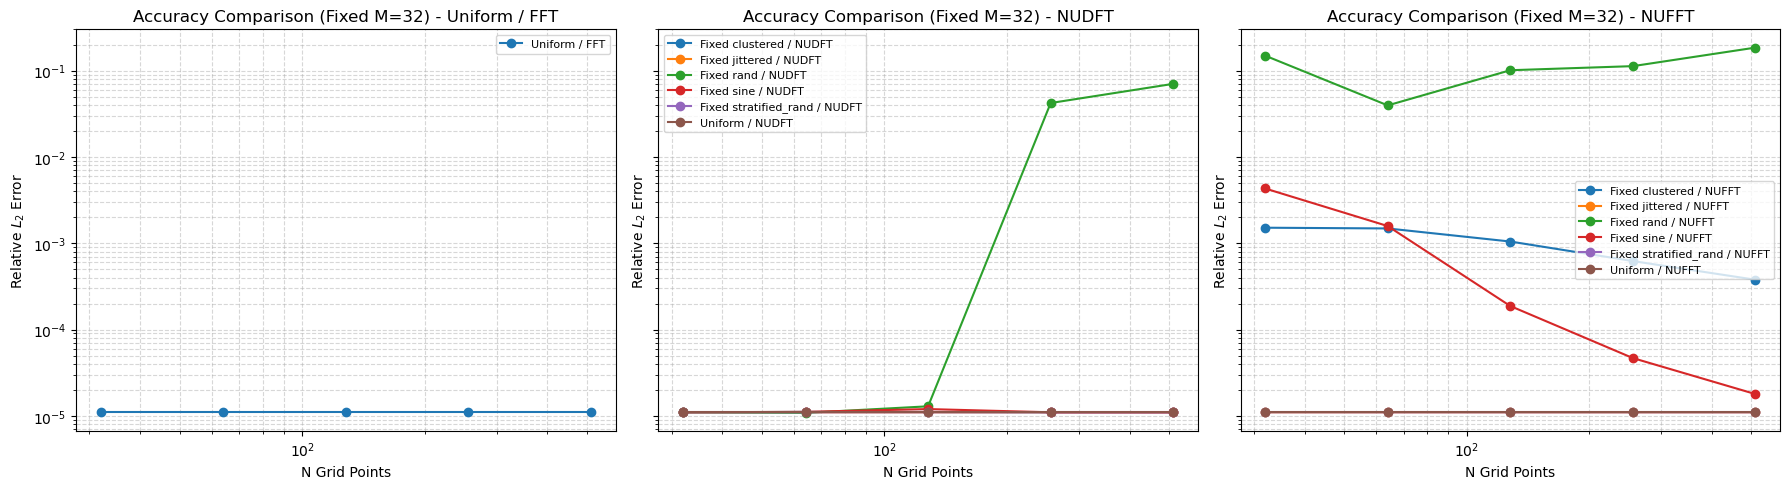

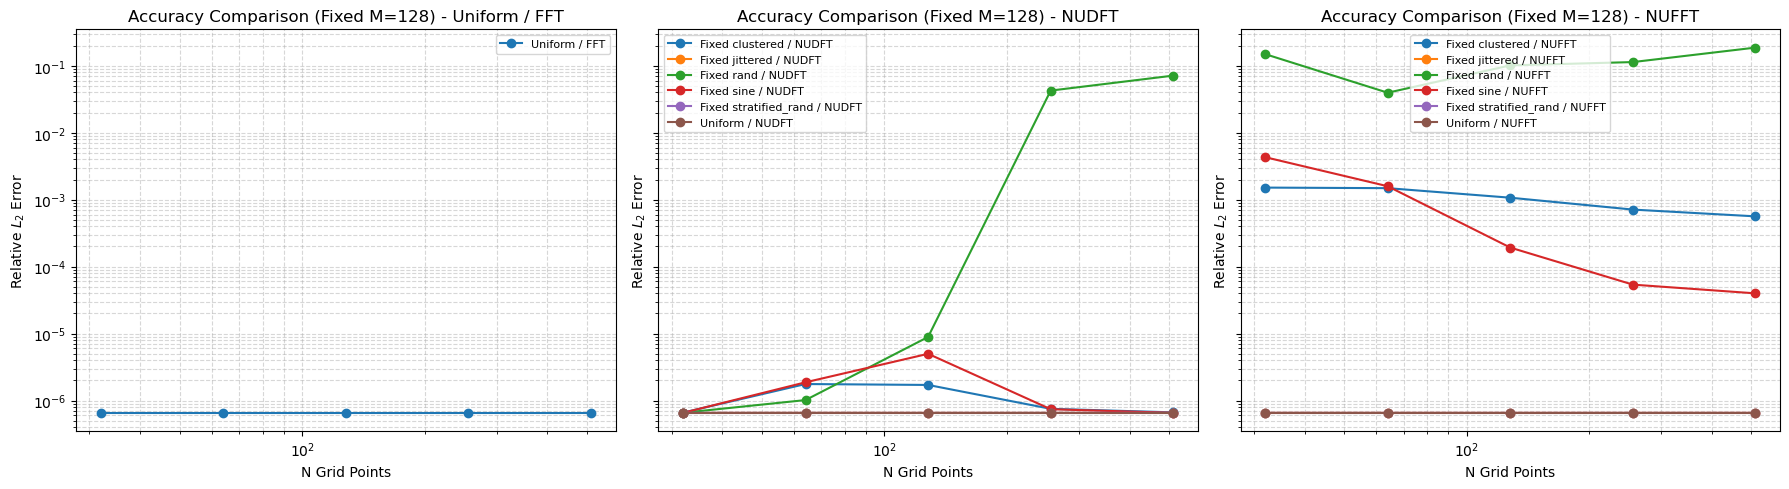

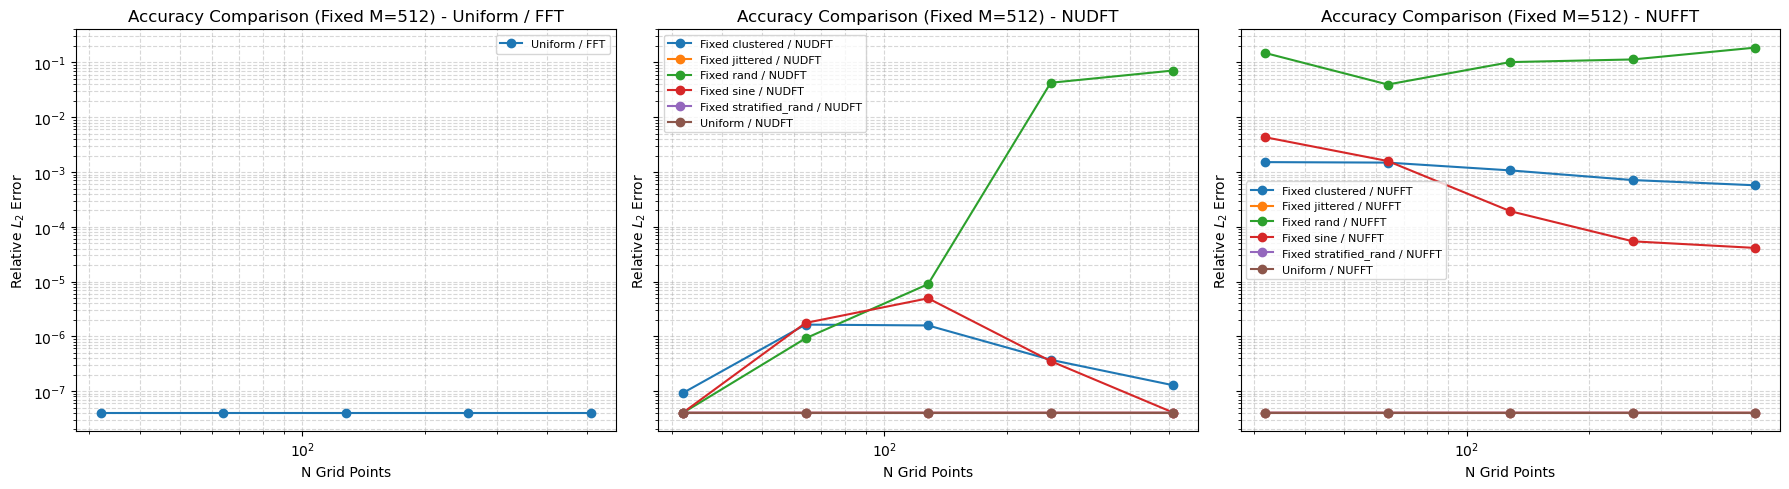

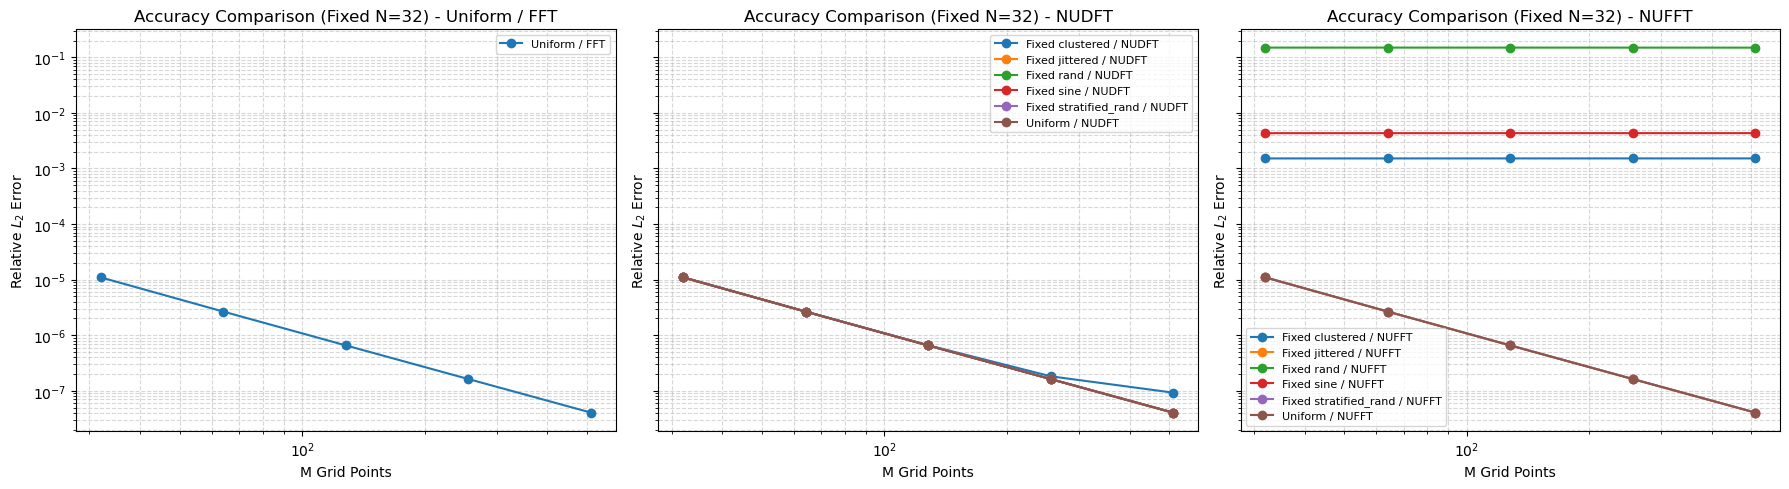

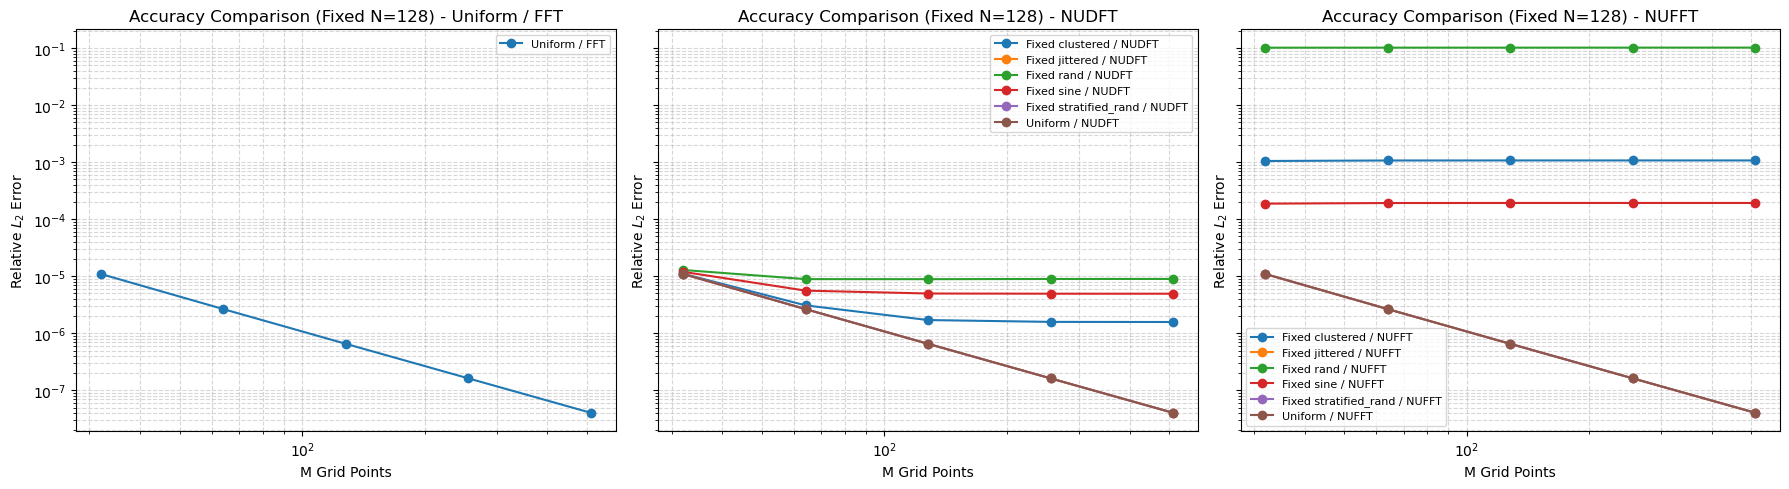

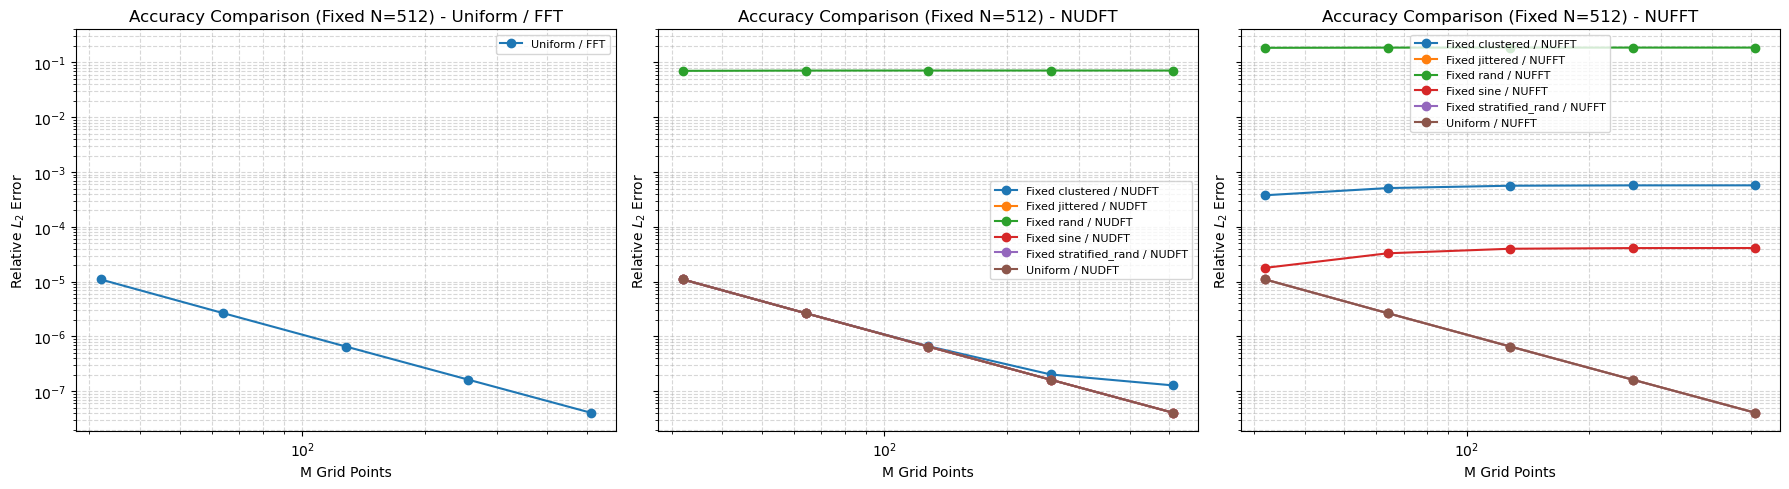


Accuracy Comparison (Fixed M=32) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.51e-03,1.10e-05,1.49e-01,4.31e-03,1.10e-05
64,1.10e-05,1.10e-05,1.10e-05,1.11e-05,1.10e-05,1.08e-05,1.11e-05,1.10e-05,1.48e-03,1.10e-05,3.96e-02,1.58e-03,1.10e-05
128,1.10e-05,1.10e-05,1.10e-05,1.11e-05,1.10e-05,1.29e-05,1.20e-05,1.10e-05,1.05e-03,1.10e-05,1.01e-01,1.87e-04,1.10e-05
256,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,4.22e-02,1.10e-05,1.10e-05,6.21e-04,1.10e-05,1.13e-01,4.67e-05,1.10e-05
512,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,7.04e-02,1.10e-05,1.10e-05,3.77e-04,1.10e-05,1.85e-01,1.79e-05,1.10e-05



Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.60e-07,6.55e-07,6.56e-07,6.55e-07,6.56e-07,1.51e-03,6.55e-07,1.49e-01,4.31e-03,6.56e-07
64,6.55e-07,6.55e-07,6.55e-07,1.76e-06,6.55e-07,1.02e-06,1.87e-06,6.55e-07,1.49e-03,6.55e-07,3.96e-02,1.59e-03,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,1.71e-06,6.55e-07,8.90e-06,4.99e-06,6.55e-07,1.07e-03,6.55e-07,1.01e-01,1.92e-04,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,7.52e-07,6.55e-07,4.26e-02,7.42e-07,6.55e-07,7.11e-04,6.55e-07,1.14e-01,5.38e-05,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,6.66e-07,6.55e-07,7.13e-02,6.55e-07,6.55e-07,5.63e-04,6.55e-07,1.87e-01,3.99e-05,6.55e-07



Accuracy Comparison (Fixed M=512) Accuracy


...

label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.51e-03,1.10e-05,1.49e-01,4.31e-03,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.67e-06,2.66e-06,2.66e-06,1.51e-03,2.66e-06,1.49e-01,4.31e-03,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.60e-07,6.55e-07,6.56e-07,6.55e-07,6.56e-07,1.51e-03,6.55e-07,1.49e-01,4.31e-03,6.56e-07
256,1.62e-07,1.62e-07,1.62e-07,1.82e-07,1.62e-07,1.62e-07,1.62e-07,1.63e-07,1.52e-03,1.62e-07,1.49e-01,4.32e-03,1.63e-07
512,4.04e-08,4.04e-08,4.04e-08,9.25e-08,4.05e-08,4.01e-08,4.05e-08,4.05e-08,1.52e-03,4.05e-08,1.49e-01,4.32e-03,4.05e-08



Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.11e-05,1.10e-05,1.29e-05,1.20e-05,1.10e-05,1.05e-03,1.10e-05,1.01e-01,1.87e-04,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,3.09e-06,2.66e-06,8.91e-06,5.60e-06,2.66e-06,1.07e-03,2.66e-06,1.01e-01,1.92e-04,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,1.71e-06,6.55e-07,8.90e-06,4.99e-06,6.55e-07,1.07e-03,6.55e-07,1.01e-01,1.92e-04,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.59e-06,1.62e-07,8.96e-06,4.95e-06,1.62e-07,1.07e-03,1.62e-07,1.01e-01,1.93e-04,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,1.58e-06,4.04e-08,8.98e-06,4.95e-06,4.04e-08,1.07e-03,4.04e-08,1.02e-01,1.93e-04,4.05e-08



Accuracy Comparison (Fixed N=512) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,7.04e-02,1.10e-05,1.10e-05,3.77e-04,1.10e-05,1.85e-01,1.79e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,7.12e-02,2.66e-06,2.66e-06,5.10e-04,2.66e-06,1.87e-01,3.29e-05,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.66e-07,6.55e-07,7.13e-02,6.55e-07,6.55e-07,5.63e-04,6.55e-07,1.87e-01,3.99e-05,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,2.03e-07,1.62e-07,7.13e-02,1.62e-07,1.62e-07,5.72e-04,1.62e-07,1.87e-01,4.10e-05,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,1.28e-07,4.04e-08,7.13e-02,4.05e-08,4.04e-08,5.72e-04,4.04e-08,1.87e-01,4.11e-05,4.04e-08


In [3]:
# Accuracy plots for varying N (different fixed M)
for fixed_m, df_cN in df_cN_by_M.items():
    plot_accuracy_comparison(
        df_cN,
        index_col="N",
        title_prefix=f"Accuracy Comparison (Fixed M={fixed_m})",
    )


# Accuracy plots for varying M (different fixed N)
for fixed_n, df_cM in df_cM_by_N.items():
    plot_accuracy_comparison(
        df_cM,
        index_col="M",
        title_prefix=f"Accuracy Comparison (Fixed N={fixed_n})",
    )


for fixed_m, df_cN in df_cN_by_M.items():
    render_accuracy(
        df_cN,
        index_col="N",
        columns_col="label",
        title_prefix=f"Accuracy Comparison (Fixed M={fixed_m})",
    )

# Accuracy plots for varying M (different fixed N)
for fixed_n, df_cM in df_cM_by_N.items():
    render_accuracy(
        df_cM,
        index_col="M",
        columns_col="label",
        title_prefix=f"Accuracy Comparison (Fixed N={fixed_n})",
    )



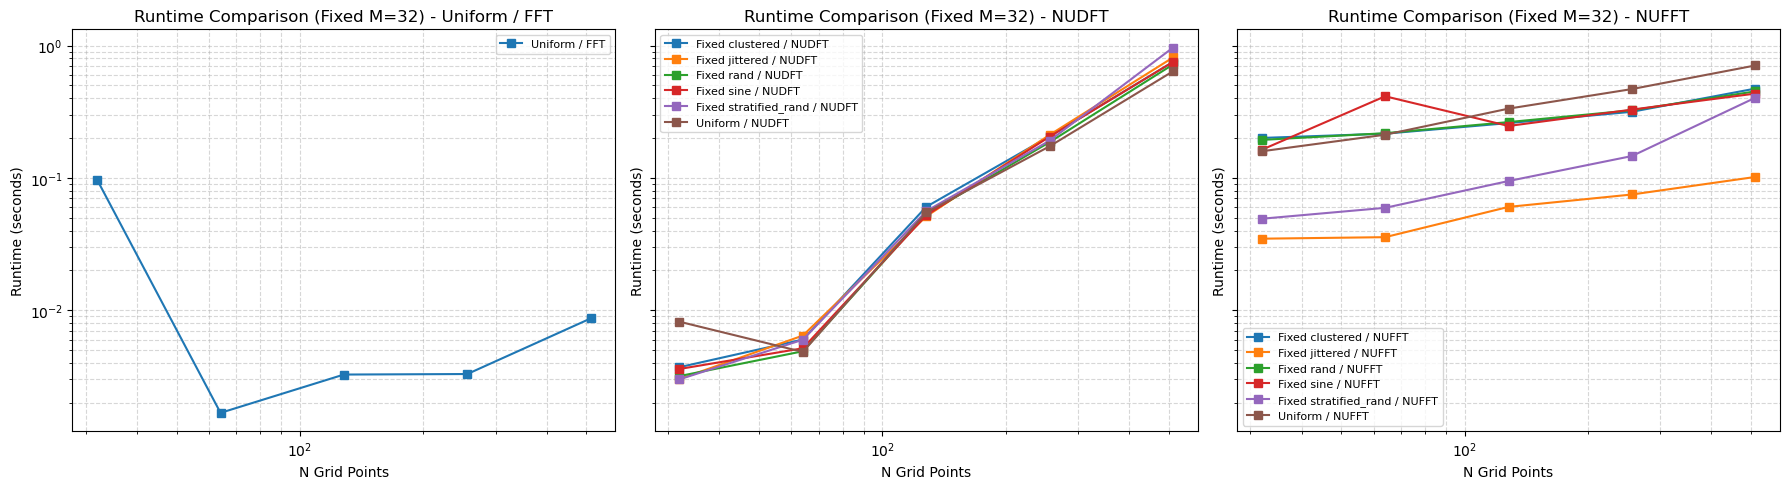

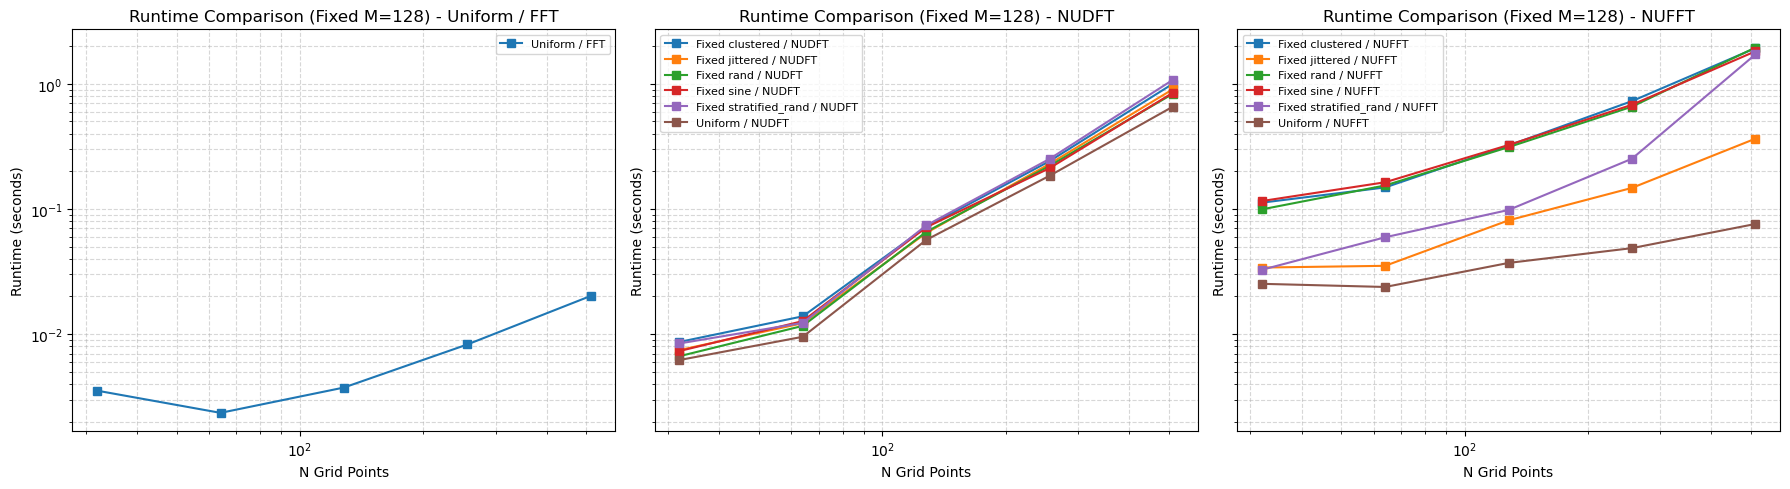

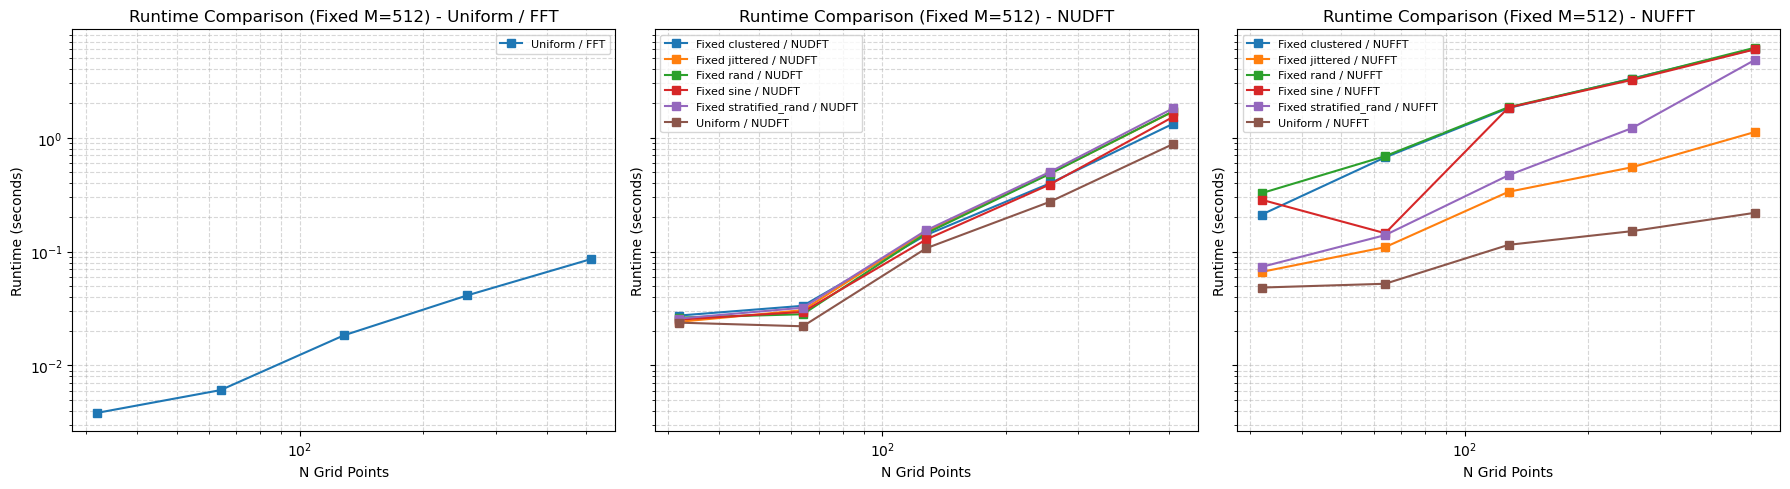

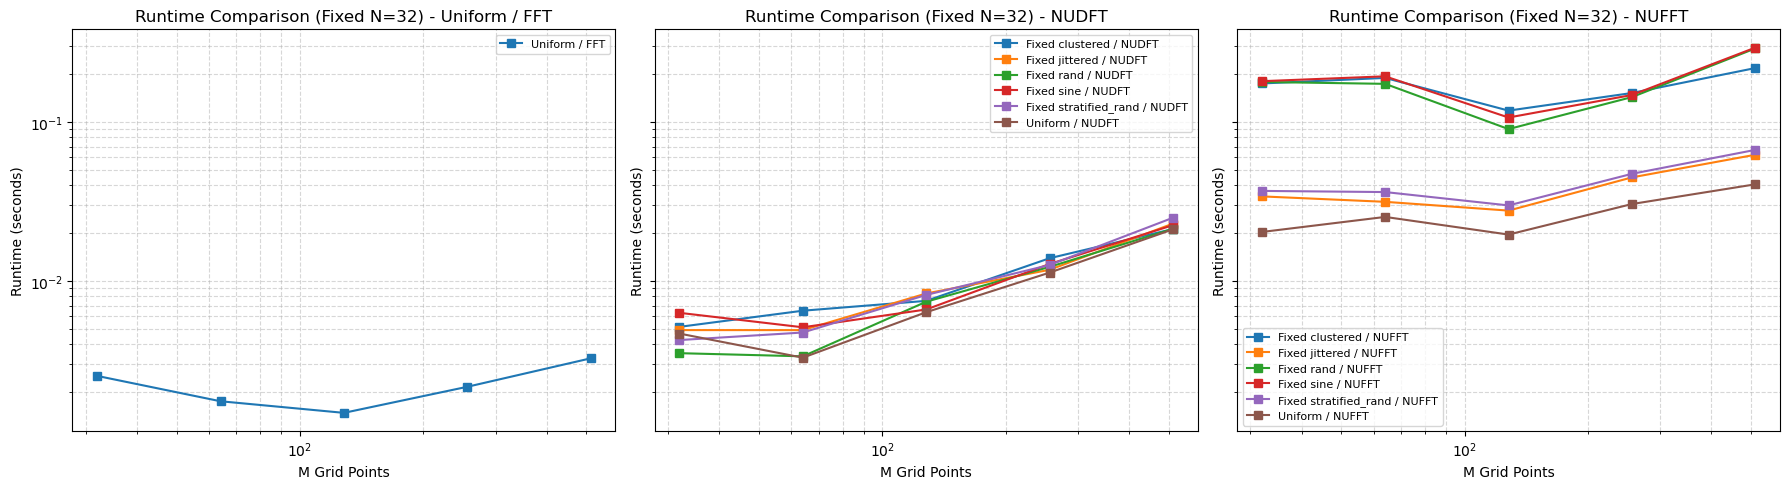

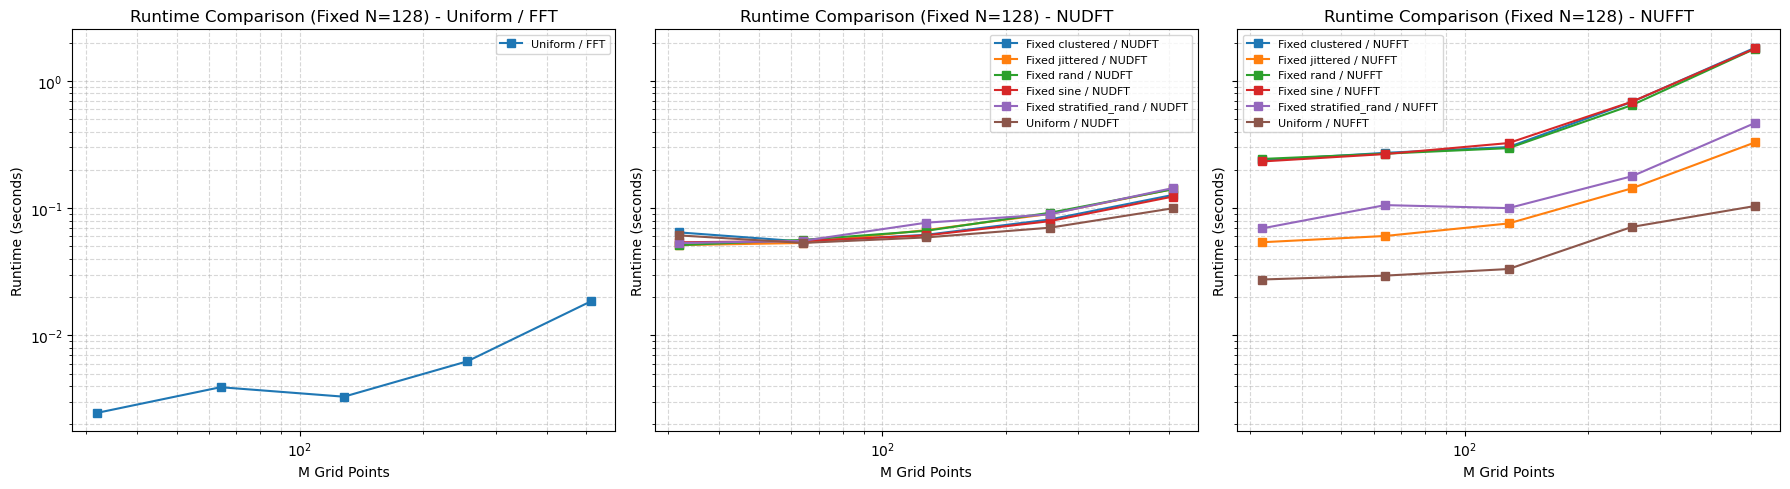

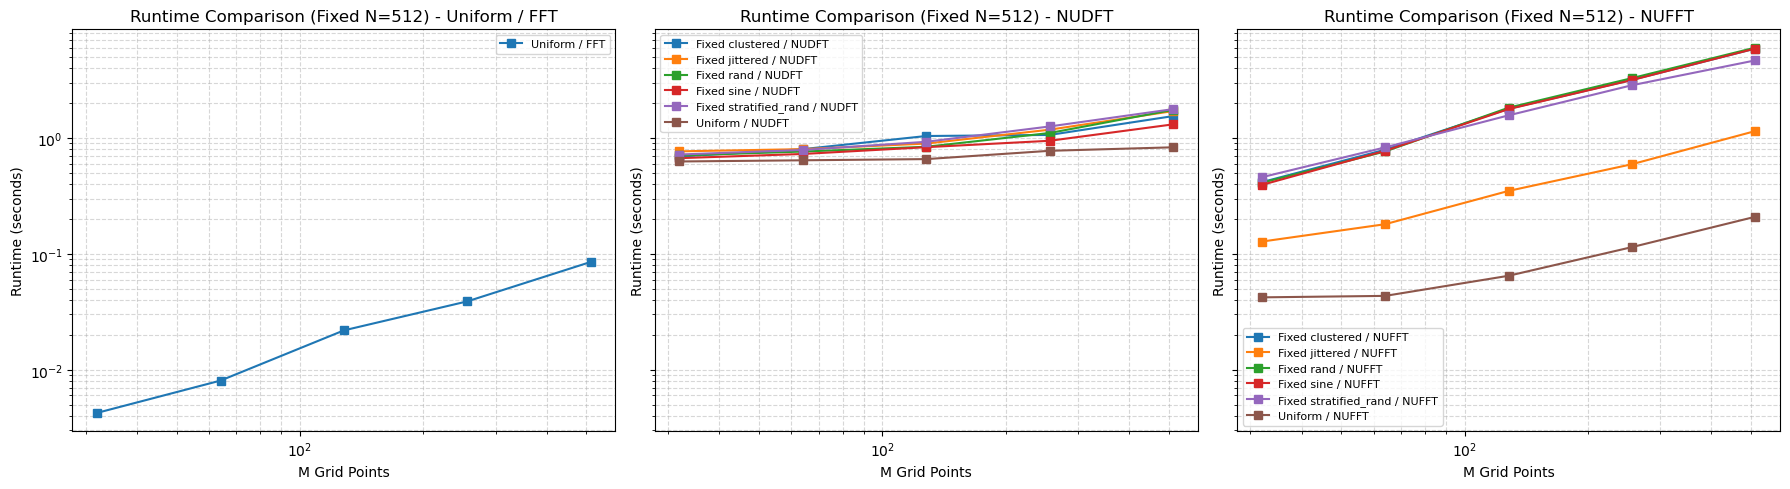

Accuracy Comparison (Fixed M=32) Runtimes

Runtime Comparison (Fixed M=32) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,0.0967,0.0082,0.1589,0.0037,0.0030,0.0032,0.0036,0.0030,0.2004,0.0347,0.1936,0.1630,0.0491
64,0.0017,0.0048,0.2119,0.0060,0.0064,0.0049,0.0052,0.0060,0.2158,0.0356,0.2176,0.4137,0.0594
128,0.0033,0.0548,0.3336,0.0604,0.0512,0.0531,0.0521,0.0560,0.2594,0.0603,0.2640,0.2467,0.0947
256,0.0033,0.1733,0.4689,0.2060,0.2114,0.1863,0.2049,0.1912,0.3159,0.0749,0.3243,0.3280,0.1462
512,0.0087,0.6390,0.7071,0.7515,0.8125,0.7191,0.7520,0.9649,0.4728,0.1016,0.4504,0.4336,0.4035


Accuracy Comparison (Fixed M=128) Runtimes

Runtime Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,,,,,,,
32,0.0035,0.0062,0.0252,0.0087,0.0075,0.0067,0.0073,0.0084,0.1123,0.0340,0.0992,0.1157,0.0326
64,0.0023,0.0095,0.0238,0.0139,0.0122,0.0116,0.0127,0.0123,0.1486,0.0351,0.1541,0.1635,0.0594
128,0.0037,0.0566,0.0371,0.0719,0.0643,0.0656,0.0714,0.0739,0.3214,0.0811,0.3119,0.3244,0.0981
256,0.0083,0.1843,0.0487,0.2411,0.2294,0.2211,0.2120,0.2513,0.7269,0.1473,0.6566,0.6796,0.2519
512,0.0202,0.6578,0.0758,1.0025,0.9064,0.8334,0.8499,1.0775,1.9254,0.3642,1.9468,1.8174,1.7153


Accuracy Comparison (Fixed M=512) Runtimes

Runtime Comparison (Fixed M=512) Runtime (s)


...

label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,0.0025,0.0047,0.0203,0.0051,0.0049,0.0035,0.0063,0.0042,0.1747,0.0340,0.1785,0.1805,0.0369
64,0.0018,0.0033,0.0253,0.0065,0.0049,0.0034,0.0051,0.0047,0.1893,0.0315,0.1737,0.1937,0.0362
128,0.0015,0.0064,0.0196,0.0075,0.0083,0.0074,0.0066,0.0082,0.1179,0.0277,0.0902,0.1067,0.0299
256,0.0022,0.0113,0.0305,0.0139,0.0118,0.0123,0.0128,0.0126,0.1522,0.0448,0.1434,0.1478,0.0472
512,0.0033,0.0211,0.0405,0.0212,0.0230,0.0213,0.0224,0.0250,0.2184,0.0622,0.2903,0.2937,0.0668


Accuracy Comparison (Fixed N=128) Runtimes

Runtime Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,0.0025,0.0611,0.0275,0.0645,0.0513,0.0512,0.0539,0.0532,0.2378,0.0540,0.2437,0.2328,0.0693
64,0.0039,0.0533,0.0295,0.0547,0.0533,0.0563,0.0552,0.0553,0.2722,0.0605,0.2682,0.2664,0.1057
128,0.0033,0.0589,0.0332,0.0617,0.0672,0.0664,0.0611,0.0769,0.3023,0.0759,0.2965,0.3250,0.1001
256,0.0063,0.0702,0.0712,0.0814,0.0902,0.0919,0.0791,0.0894,0.6845,0.1432,0.6458,0.6869,0.1782
512,0.0185,0.0998,0.1041,0.1271,0.1413,0.1408,0.1234,0.1440,1.8290,0.3296,1.7975,1.8036,0.4684


Accuracy Comparison (Fixed N=512) Runtimes

Runtime Comparison (Fixed N=512) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed stratified_rand / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,,,,,,,
32,0.0042,0.6279,0.0421,0.6922,0.7682,0.7080,0.6709,0.7212,0.4160,0.1277,0.4112,0.3938,0.4589
64,0.0081,0.6428,0.0434,0.8024,0.8022,0.7648,0.7290,0.7895,0.7938,0.1804,0.7663,0.7768,0.8311
128,0.0219,0.6582,0.0647,1.0418,0.8966,0.8412,0.8343,0.9283,1.7902,0.3497,1.8279,1.7788,1.5704
256,0.0389,0.7763,0.1144,1.0642,1.1812,1.1061,0.9475,1.2596,3.1803,0.5945,3.2912,3.1694,2.8589
512,0.0852,0.8323,0.2093,1.5474,1.7100,1.7514,1.3130,1.7776,5.9268,1.1498,6.0417,5.9281,4.6853


In [4]:
# Runtime plots/tables for varying N
for fixed_m, df_cN in df_cN_by_M.items():
    plot_runtime_comparison(
        df_cN,
        index_col="N",
        title_prefix=f"Runtime Comparison (Fixed M={fixed_m})",
    )


# Runtime plots/tables for varying M
for fixed_n, df_cM in df_cM_by_N.items():
    plot_runtime_comparison(
        df_cM,
        index_col="M",
        title_prefix=f"Runtime Comparison (Fixed N={fixed_n})",
    )


# Runtime plots/tables for varying N
for fixed_m, df_cN in df_cN_by_M.items():

    print(f"Accuracy Comparison (Fixed M={fixed_m}) Runtimes")
    render_runtime(
        df_cN,
        index_col="N",
        columns_col="label",
        title_prefix=f"Runtime Comparison (Fixed M={fixed_m})",
    )

# Runtime plots/tables for varying M
for fixed_n, df_cM in df_cM_by_N.items():
    print(f"Accuracy Comparison (Fixed N={fixed_n}) Runtimes")
    render_runtime(
        df_cM,
        index_col="M",
        columns_col="label",
        title_prefix=f"Runtime Comparison (Fixed N={fixed_n})",
    )